[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/josterri/predicting-the-next-words-notebooks/blob/main/ch12_workbook.ipynb)

# Rewards from preferences and the KL-regularised policy

The Bradley–Terry model turns the gap between the rewards of two answers into
the chance that a person prefers one of them, so preferences drawn from it fix
every gap between rewards and leave a constant added to all of them free. A
policy that maximises a reward under a KL penalty re-weights a reference
policy by the exponential of each answer's reward divided by β.

In [1]:
#@title Setup: run this cell first
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

NAMES = ["A", "B", "C", "D", "E", "F", "B padded", "D padded"]
QUALITY = np.array([-1.5, -0.9, -0.3, 0.3, 0.9, 1.5])  # true rewards of six answers to one prompt
TOKENS = np.array([80, 120, 100, 180, 260, 220, 600, 600])
Q8 = np.r_[QUALITY, QUALITY[[1, 3]]]  # B and D again, padded with repetition and no content added
REF = np.array([0.10, 0.15, 0.20, 0.20, 0.15, 0.10, 0.05, 0.05])  # π_ref, the SFT model
N = 3000
I, J = np.array([(a, b) for a in range(6) for b in range(a)]).T  # the answers of each pair


# A setting a cell refuses: Colab prints the one sentence, without the stack.
class Refused(Exception):
    _render_traceback_ = lambda self: [str(self)]  # noqa: E731


# The refusal names the value as typed, cut to 40 characters with an ellipsis, its type and
# the range.
#% Python 3.13 refuses to print an int of more than 4,300 digits, so a long int is named by
#% its bits.
def need(ok, name, value, rule):
    if not ok:
        shown = repr(value) if not isinstance(value, int) or value.bit_length() <= 128 else f"an int of {value.bit_length():,} bits"
        shown = shown if len(shown) <= 40 else shown[:39] + "…"
        raise Refused(f"{name} is {shown}, of type {type(value).__name__}: {name} takes {rule}.")


# value as a float when it is a number from low to high; otherwise a refusal naming the range.
def number(name, value, low, high):
    real = type(value) in (int, float) or isinstance(value, (np.integer, np.floating))
    need(real and low <= value <= high, name, value, f"a number from {low:g} to {high:g}")
    return float(value)


# The values of β the appendix draws, each checked as BETA is.
def betas(values):
    need(isinstance(values, (list, tuple)) and 1 <= len(values) <= 9, "BETAS", values, "a list of 1 to 9 values of β")
    return [number("each β in BETAS", b, 0.001, 1000) for b in values]


# The logistic function 1 / (1 + e^(−z)), as exp(−log(1 + e^(−z))) so that no exp overflows.
def sigma(z):
    return np.exp(-np.logaddexp(0, -z))


# σ against the reward gap, with the point at gap.
def bt_show(gap):
    gap = number("GAP", gap, 0, 30)
    d = np.linspace(-max(6, gap + 1), max(6, gap + 1), 401)
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.plot(d, sigma(d), label="Bradley–Terry, σ(gap)")
    ax.axhline(0.5, color="gray", ls=":", label="0.5, no preference")
    ax.plot(gap, sigma(gap), "D", color="C3", ms=8, label=f"gap {gap:g}: chance {sigma(gap):.4f}")
    ax.set(xlabel="reward gap, r(x, y₁) − r(x, y₂)", ylabel="chance that y₁ is preferred", ylim=(-0.04, 1.06))
    ax.legend(loc="upper left", fontsize=8)
    plt.show()


# Logistic regression on reward differences: one reward per answer, mean 0, by Newton's method.
# Row k compares answer i[k] with answer j[k], and won[k] is 1 when i[k] was preferred.
def fit(i, j, won):
    X = np.eye(6)[i] - np.eye(6)[j]
    r = np.zeros(6)
    #% Twenty-five Newton steps: over every FLIP from 0 to 1 in steps of 1/N and seeds 0 to 19,
    #% 60,020 fits, the gradient falls below 1e-9 within five and ends below 6e-13
    #% (.work/ch12/converge.py). The Hessian is singular along a constant added to every reward;
    #% lstsq takes the step with no such constant, so the rewards keep mean 0.
    for _ in range(25):
        p = sigma(X @ r)
        r += np.linalg.lstsq((X * (p * (1 - p))[:, None]).T @ X, X.T @ (won - p), rcond=None)[0]
    return r - r.mean()


# Rewards fitted from N comparisons of seed's draw, with a share flip of the labels reversed.
def fit_rewards(flip, seed=0):
    rng = np.random.default_rng(seed)
    i = rng.integers(6, size=N)
    j = (i + rng.integers(1, 6, size=N)) % 6  # each of the five other answers equally often
    won = rng.random(N) < sigma(QUALITY[i] - QUALITY[j])
    won[rng.permutation(N)[:round(flip * N)]] ^= True
    return fit(i, j, won.astype(float))


# The true and the fitted reward of A to F, one pair of bars per answer, each labelled with
# its value.
def reward_bars(fitted, flip):
    fig, ax = plt.subplots(figsize=(6, 3.5))
    true = ax.barh(np.arange(6) - 0.2, QUALITY, 0.4, label="true reward", color="white", edgecolor="C0", hatch="//")
    fits = ax.barh(np.arange(6) + 0.2, fitted, 0.4, label=f"fitted, {flip:g} of labels reversed")
    for bars in (true, fits):
        ax.bar_label(bars, fmt="%.2f", fontsize=8, padding=3)
    ax.axvline(0, color="black", lw=0.8)
    ax.set(yticks=range(6), yticklabels=NAMES[:6], ylim=(5.6, -0.6), ylabel="answer", xlabel="reward, mean 0",
           xlim=(-2.2, 2.2))
    ax.legend(loc="lower left", bbox_to_anchor=(0, 1), ncol=2, fontsize=8, frameon=False)
    plt.show()


# The eight answers' rewards: the quality, plus 0.5 for every 100 tokens when bias is True.
def reward(bias):
    need(isinstance(bias, (bool, np.bool_)), "LENGTH_BIAS", bias, "True or False")
    return Q8 + (0.5 * TOKENS / 100 if bias else 0)


# The eight answers by reward, highest first, equal rewards in the order of NAMES; padded
# ones hatched.
def ranking(r):
    order = np.argsort(-r, kind="stable")
    fig, ax = plt.subplots(figsize=(6, 3.5))
    bars = ax.barh(range(8), r[order], color=np.where(order >= 6, "white", "C1"), edgecolor="k",
                   hatch=np.where(order >= 6, "//", ""))
    ax.bar_label(bars, fmt="%.2f", fontsize=8, padding=3)
    ax.set_yticks(range(8), [f"{NAMES[k]}, {TOKENS[k]} tokens, quality {Q8[k]:.1f}" for k in order], fontsize=8)
    ax.axvline(0, color="black", lw=0.8)
    ax.set(xlabel="reward r(x, y)", xlim=(-2.2, 4.2), ylim=(7.6, -0.6))
    plt.show()


# π*(y | x) = π_ref(y | x) · exp(r(x, y) / β) / Z(x) for the length-biased reward, with
# log Z(x) summed in logs, so that no exp overflows.
def policy(beta):
    z = np.log(REF) + R / beta
    return np.exp(z - np.logaddexp.reduce(z))


# D_KL(π ‖ π_ref) = Σ π log(π / π_ref) in nats, with 0 · log 0 taken as 0.
def kl(p):
    return float(np.sum(p * np.log(np.where(p > 0, p, 1) / REF)))


R = reward(True)
display(Markdown(f"Six answers A to F to one prompt; B and D also padded to {TOKENS[6]} tokens."))

Six answers A to F to one prompt; B and D also padded to 600 tokens.

## 1. The chance of a preference depends on the reward gap alone

Answer y₁ to a prompt has a reward `GAP` above the reward of answer y₂, and
the Bradley–Terry model gives the chance that a person prefers y₁. Run the
cell, then set `GAP = 3` and run it again: how likely is y₁ to be preferred
at each gap, and what does that chance become when both rewards rise by 100?

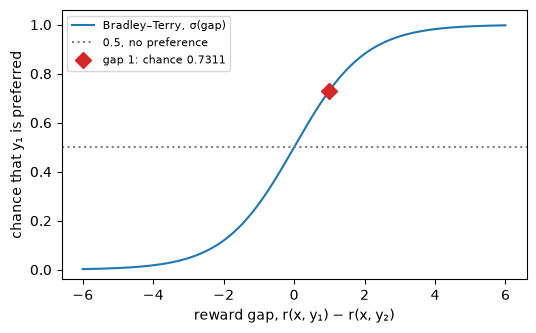

In [2]:
GAP = 1
bt_show(GAP)

### Solution

In [3]:
gap = number("GAP", GAP, 0, 30)
display(Markdown(f"At a gap of {gap:g}, y₁ is preferred with chance σ({gap:g}) = {sigma(gap):.4f} and y₂ with "
    f"{sigma(-gap):.4g}; at a gap of 3 the chance for y₁ is {sigma(3):.4f}. With 100 added to both rewards the "
    f"gap stays {gap:g} and the chance {sigma((gap + 100) - (0 + 100)):.4f}: the model reads the gap alone. A "
    f"label y₁ ≻ y₂ costs the binary cross-entropy −log σ({gap:g}) = {np.logaddexp(0, -gap):.4g} nats."))

At a gap of 1, y₁ is preferred with chance σ(1) = 0.7311 and y₂ with 0.2689; at a gap of 3 the chance for y₁ is 0.9526. With 100 added to both rewards the gap stays 1 and the chance 0.7311: the model reads the gap alone. A label y₁ ≻ y₂ costs the binary cross-entropy −log σ(1) = 0.3133 nats.

## 2. Rewards fitted from preferences with reversed labels

Six answers A to F have true rewards from −1.5 to 1.5. In 3,000
comparisons of two of them, drawn at random from seed 0, the Bradley–Terry
model with the true rewards picks the preferred answer, and a share `FLIP` of
the labels, chosen at random, is then recorded the wrong way round. Logistic
regression on the reward differences fits one reward per answer, with mean 0.
Run the cell, then set `FLIP` to 0 and to 0.4: does the fitted reward keep the
true order of the six answers, and how far above A does it put F?

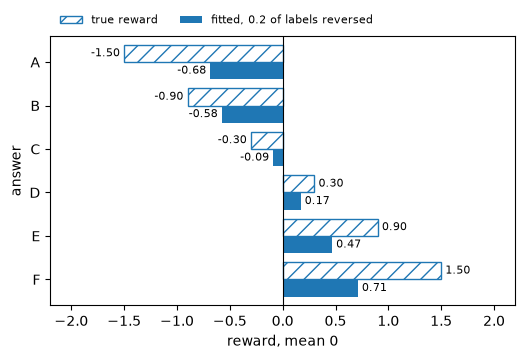

In [4]:
FLIP = 0.2
reward_bars(fit_rewards(number("FLIP", FLIP, 0, 1)), FLIP)

### Solution

In [5]:
flip = number("FLIP", FLIP, 0, 1)
fits = [fit_rewards(flip, s) for s in range(20)]
f_a = [r[5] - r[0] for r in fits]  # F − A, signed
kept = [sum((r[a] - r[b]) * (QUALITY[a] - QUALITY[b]) > 0 for a, b in zip(I, J)) for r in fits]
#% The fit that unlimited comparisons approach: each pair's label is its expected value.
lim = fit(I, J, flip + (1 - 2 * flip) * sigma(QUALITY[I] - QUALITY[J]))
ratio = [(lim[a] - lim[b]) / (QUALITY[a] - QUALITY[b]) for a, b in zip(I, J)]
d_c = sigma(QUALITY[3] - QUALITY[2])  # D against C, the closest pair
display(Markdown(f"Reversing a share f of the labels moves the chance that a label prefers the better answer "
    f"from σ(gap) to f + (1 − 2f) · σ(gap): for D against C from {d_c:.3f} to {flip + (1 - 2 * flip) * d_c:.3f} at "
    f"f = {flip:g}. Unlimited comparisons would give a fit with F − A = {lim[5] - lim[0]:+.2f}, against "
    f"{QUALITY[5] - QUALITY[0]:+.2f} for the true rewards: each of the {len(I)} fitted gaps would be {min(ratio):+.2f} "
    f"to {max(ratio):+.2f} times its true gap, and a negative factor reverses the order. From seed 0's {N:,} "
    f"comparisons F − A is {f_a[0]:+.2f}, and the fit orders {kept[0]} of the {len(I)} pairs as the true rewards "
    f"do; seeds 0 to {len(fits) - 1} put F − A between {min(f_a):+.2f} and {max(f_a):+.2f}, and "
    f"{kept.count(len(I))} of the {len(fits)} order every pair as the true rewards do."))

Reversing a share f of the labels moves the chance that a label prefers the better answer from σ(gap) to f + (1 − 2f) · σ(gap): for D against C from 0.646 to 0.587 at f = 0.2. Unlimited comparisons would give a fit with F − A = +1.44, against +3.00 for the true rewards: each of the 15 fitted gaps would be +0.46 to +0.51 times its true gap, and a negative factor reverses the order. From seed 0's 3,000 comparisons F − A is +1.39, and the fit orders 15 of the 15 pairs as the true rewards do; seeds 0 to 19 put F − A between +1.34 and +1.67, and 20 of the 20 order every pair as the true rewards do.

## 3. A length bonus of 0.5 per 100 tokens puts a padded answer first

B and D come a second time, padded with repetition to 600 tokens and no
content added, so each keeps its quality, its true reward. With
`LENGTH_BIAS = True` the reward is the quality plus a length bonus of 0.5
for every 100 tokens; with `False` it is the quality alone. Run the cell, then
set `LENGTH_BIAS = False` and run it again: which answer does each reward rank
first, and how does its quality compare with the best answer's?

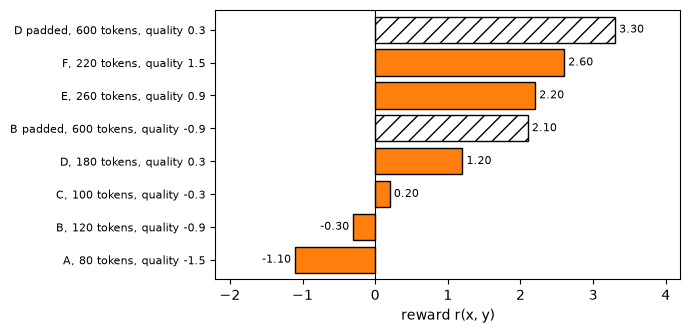

In [6]:
LENGTH_BIAS = True
ranking(reward(LENGTH_BIAS))

### Solution

In [7]:
r = reward(LENGTH_BIAS)
order = np.argsort(-r, kind="stable")
top = order[0]
best = int(np.argmax(Q8))
ties = " ".join(f"{NAMES[a]} and {NAMES[b]} tie at {r[a]:.2f}, and the tie goes to {NAMES[a]}, listed first."
                for a, b in zip(order, order[1:]) if r[a] == r[b])
how = (f"its quality is {Q8[top]:.1f}, against {Q8[best]:.1f} for {NAMES[best]}, the best answer" if top != best
       else "it is the answer of highest quality")
display(Markdown(f"{'With' if LENGTH_BIAS else 'Without'} the length bonus the reward ranks {NAMES[top]} first, at "
                 f"{r[top]:.2f}, and {how}. {ties or 'No two answers tie.'} D padded passes {NAMES[best]} once the "
                 f"bonus exceeds {100 * (Q8[best] - Q8[7]) / (TOKENS[7] - TOKENS[best]):.3f} per 100 tokens."))

With the length bonus the reward ranks D padded first, at 3.30, and its quality is 0.3, against 1.5 for F, the best answer. No two answers tie. D padded passes F once the bonus exceeds 0.316 per 100 tokens.

## Appendix. The KL-regularised policy

The Bradley–Terry model gives the chance that a person prefers answer y_w to
answer y_l for a prompt x from the difference of their rewards,

P(y_w ≻ y_l | x) = σ(r(x, y_w) − r(x, y_l)),  σ(z) = 1 / (1 + e^(−z)),

and a reward model r_φ is fitted to labelled pairs by minimising

L_RM = −E_(x, y_w, y_l)[log σ(r_φ(x, y_w) − r_φ(x, y_l))],

binary cross-entropy with the reward difference as the logit and a target of
1. A constant added to every reward leaves every difference unchanged, so the
fit fixes the rewards up to that constant, and their mean of 0 fixes it.

RLHF then looks for the policy π that maximises the reward and stays near the
reference policy π_ref, the SFT model:

max over π of  E_(y ∼ π)[r(x, y)] − β · D_KL(π ‖ π_ref),  with
D_KL(π ‖ π_ref) = Σ_y π(y | x) · log(π(y | x) / π_ref(y | x)).

The policy that attains the maximum has a closed form,

π*(y | x) = π_ref(y | x) · exp(r(x, y) / β) / Z(x),  Z(x) = Σ_y π_ref(y | x) · exp(r(x, y) / β),

the reference with every answer re-weighted by its exponentiated reward, β
dividing the reward. As β → 0 the policy puts all its probability on the
answers of highest reward, which is unconstrained reward maximisation; as
β → ∞ it returns to π_ref.

For the eight answers, r is the reward with the length bonus, and π_ref gives
A to F between 0.1 and 0.2 each and each padded answer 0.05. The policy π* for
β from 100 down to 0.01:

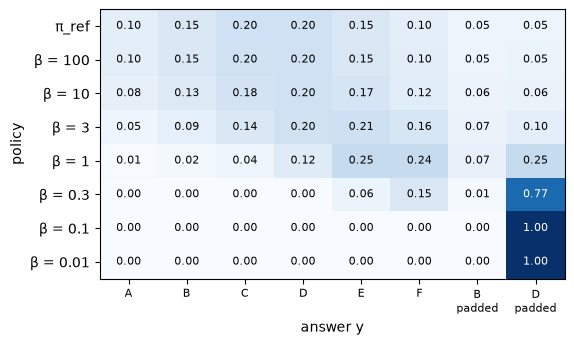

In [8]:
BETAS = [100, 10, 3, 1, 0.3, 0.1, 0.01]
P = np.array([REF] + [policy(b) for b in betas(BETAS)])
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.imshow(P, cmap="Blues", vmin=0, vmax=1, aspect="auto")
for (a, b), v in np.ndenumerate(P):
    ink = "white" if v > 0.6 else "black"
    ax.text(b, a, f"{v:.2f}", ha="center", va="center", fontsize=8, color=ink)
ax.set_xticks(range(8), [n.replace(" ", "\n") for n in NAMES], fontsize=8)
ax.set_yticks(range(len(P)), ["π_ref"] + [f"β = {b:g}" for b in BETAS])
ax.set(xlabel="answer y", ylabel="policy")
plt.show()

**Exercise.** Set `BETA` to 10, 1, 0.3 and 0.1 in turn and rerun the cell.
What share of π* do the two padded answers take at each β, and at which of
the four is the policy's mean quality highest?

In [9]:
BETA = 1

p = policy(number("BETA", BETA, 0.001, 1000))
print(f"β = {BETA:g}: padded answers {p[6:].sum():.3f} of π*, mean quality {p @ Q8:.3f}, "
      f"mean reward {p @ R:.3f}, KL from π_ref {kl(p):.4g} nats")

β = 1: padded answers 0.320 of π*, mean quality 0.590, mean reward 2.281, KL from π_ref 0.5735 nats


### Solution

In [10]:
number("BETA", BETA, 0.001, 1000)
GRID = [0.01, 0.03, 0.1, 0.2, 0.3, 0.5, 1, 2, 3, 10, 100]
rows = [(b, p[6:].sum(), p @ Q8, p @ R, kl(p)) for b, p in zip(GRID, map(policy, GRID))]
display(Markdown("| β | padded share | mean quality | mean reward | KL from π_ref (nats) |\n| ---: | ---: | ---: | ---: | ---: |\n"
                 + "\n".join(f"| {b:g} | {s:.3f} | {q:.3f} | {m:.3f} | {k:.4g} |" for b, s, q, m, k in rows)))
q = [w[2] for w in rows]  # mean quality, in the order of GRID
#% argmax takes the first of equal values, the smaller β; the lead over every other value
#% says whether a tie decided.
k = int(np.argmax(q))
top4 = max([10, 1, 0.3, 0.1], key=lambda b: q[GRID.index(b)])
lead = q[k] - max(q[:k] + q[k + 1:])
display(Markdown(
    f"Of β = 10, 1, 0.3 and 0.1, the mean quality is highest at β = {top4:g}, {q[GRID.index(top4)]:.3f}. Of the "
    f"{len(GRID)} values drawn it is highest at β = {GRID[k]:g}, {q[k]:.4f}, {lead:.4f} above any other, against "
    f"{q[k - 1]:.4f} at {GRID[k - 1]:g} and {q[k + 1]:.4f} at {GRID[k + 1]:g}. The mean reward "
    f"{'never falls' if all(np.diff([w[3] for w in rows]) <= 0) else 'does not always rise'} as β falls, from "
    f"{rows[-1][3]:.3f} to {rows[0][3]:.3f}. At β = {GRID[0]:g} the padded answers take {rows[0][1]:.3f} of π* "
    f"and the mean quality is {rows[0][2]:.3f}, the quality of {NAMES[int(np.argmax(policy(GRID[0])))]}, against "
    f"{REF @ Q8:.3f} under π_ref; at β = {GRID[-1]:g} the KL from π_ref is {rows[-1][4]:.4g} nats."))

| β | padded share | mean quality | mean reward | KL from π_ref (nats) |
| ---: | ---: | ---: | ---: | ---: |
| 0.01 | 1.000 | 0.300 | 3.300 | 2.996 |
| 0.03 | 1.000 | 0.300 | 3.300 | 2.996 |
| 0.1 | 0.998 | 0.302 | 3.299 | 2.98 |
| 0.2 | 0.932 | 0.371 | 3.245 | 2.649 |
| 0.3 | 0.788 | 0.499 | 3.106 | 2.094 |
| 0.5 | 0.549 | 0.639 | 2.807 | 1.322 |
| 1 | 0.320 | 0.590 | 2.281 | 0.5735 |
| 2 | 0.202 | 0.374 | 1.748 | 0.1844 |
| 3 | 0.165 | 0.258 | 1.513 | 0.08663 |
| 10 | 0.118 | 0.062 | 1.148 | 0.008118 |
| 100 | 0.102 | -0.021 | 1.001 | 8.138e-05 |

Of β = 10, 1, 0.3 and 0.1, the mean quality is highest at β = 1, 0.590. Of the 11 values drawn it is highest at β = 0.5, 0.6394, 0.0497 above any other, against 0.4985 at 0.3 and 0.5897 at 1. The mean reward never falls as β falls, from 1.001 to 3.300. At β = 0.01 the padded answers take 1.000 of π* and the mean quality is 0.300, the quality of D padded, against -0.030 under π_ref; at β = 100 the KL from π_ref is 8.138e-05 nats.